In [7]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

In [8]:
import photospline

from icecube import dataio, icetray, dataclasses, simclasses
import numpy.random as random
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt
from scripts.SplineEval import evalLogPdf, evalPdf
from matplotlib.colors import LogNorm


In [9]:
file_500 = dataio.I3File('../nue_data/gen_500.i3.zst')
file_012 = dataio.I3File('../nue_data/gen_012.i3.zst')
gcd = dataio.I3File('../gcdfile/PONE_800mGrid.i3.gz')

iter = 0
for frame in file_500:
    if iter == 17:
        frame18 = frame
    if iter == 26:
        frame27 = frame

    if iter == 92:
        frame93 = frame
    if iter == 127:
        frame128 = frame
    
    iter += 1
iter = 0
for frame in file_012:
    if iter == 69:
        frame70 = frame
    
    if iter == 115:
        frame115 = frame
    iter += 1
for frame in gcd:
    gcdframe = frame
    break

In [10]:
c = 299792458
n = 1.34
def datacollect(frame):
    dt = []
    t = []
    dphilst = []
    dr = []
    xyz = []
    Etheta = []
    Ephi = []

    Epos = frame['I3MCTree'][1].pos
    doms = gcdframe['I3ModuleGeoMap']
    omkeys = frame['I3Photons'].keys()
    photons = frame['I3Photons']
    for key in omkeys:
        modulekey = dataclasses.ModuleKey(key.string, key.om)
        dompos = doms[modulekey].pos
        for photon in photons[key]:
            photon_pos = dompos + photon.pos
            xyz.append([photon_pos.x, photon_pos.y, photon_pos.z])
            flight = dompos + photon.pos - Epos
            dr.append(flight.magnitude)
            offset = flight.magnitude * n / c
            dt.append(photon.time - offset*10**9)
            t.append(photon.time)
            phi = photon.dir
            randx, randy, randz = random.uniform(-1, 1, 3)
            x = phi.x
            y = phi.y
            z = phi.z
            dx = x - randx
            dy = y - randy
            dz = z - randz
            dphi = dataclasses.I3Direction(dx, dy, dz)
            dphilst.append(dphi.zenith)
            # Etheta.append(flight.azimuth)
            # Ephi.append(flight.zenith)
            
    return np.column_stack([xyz, t, dt])
    
    

In [11]:
frame18['I3MCTree'][0].energy

1865.6831830418678

In [12]:
EventData1 = datacollect(frame18)
EventData2 = datacollect(frame27)
EventData3 = datacollect(frame70)
EventData4 = datacollect(frame93)
EventData5 = datacollect(frame128)
#EventData6 = datacollect(frame115)

In [13]:
splinefit_3d = photospline.SplineTable('../fits/splinelog_3D.fits')

In [14]:
def displacement_magnitude(pos1: np.array, pos2: np.array) -> float:
    vector = pos1 - pos2
    return np.sqrt(vector[0]**2 + vector[1]**2 + vector[2]**2)

In [15]:
def Likelihood_3d(coords: np.array, Event: np.array = EventData1):
    L = 0
    # coords should have shape [x,y,z,theta,phi,t]
    # Event has shape [N, 6] cols:(x,y,z,t,dr,dt). We only use the first 4 here
    
    event_xyz = Event[:,0:3]
    event_t = Event[:,3]
    
    
    
    # Calculate Displacement Magnitude
    diff = coords[0:3] - event_xyz
    dr = np.linalg.norm(diff, axis=1)
    # Calculate Time Residual
    dt = abs(coords[5] - event_t) - (1.34*dr/c * 1e9)

    # Construct Electron direction unit vector from zenith and azimuth
    Ex = np.sin(coords[4])*np.cos(coords[3])
    Ey = np.sin(coords[4])*np.sin(coords[3])
    Ez = np.cos(coords[4])


    # Calculate angle between electron travel vector and displacement vector
    Eangle = np.array([Ex, Ey, Ez])
    Ephi = np.arccos(np.dot(diff, Eangle) / dr)
    #print(Ephi)
    #Calculate Likelihood from constructed coordinates
    params = np.array([dr, Ephi, dt])
    vals = splinefit_3d.evaluate_simple([params[0], params[1], params[2]])
    L = np.where(vals == 0, -30, vals)
    return -np.sum(L)


In [16]:
Likelihood_3d(np.array([2.86453, 216.537, 254.435, 5.03732, 1.12255, 0]), EventData1)

34526.78937447071

In [17]:
truth = np.array([2.86453, 216.537, 254.435, 0])
def Likelihood_3d_calculation(truth, Event) -> None:
    xary = np.linspace(truth[0] - 5, truth[0] + 5, 500)
    yary = np.linspace(truth[1] - 5, truth[1] + 5, 500)
    zary = np.linspace(truth[2] - 5, truth[2] + 5, 500)
    tary = np.linspace(truth[5] - 15, truth[5] + 15, 500)
    phiary = np.linspace((truth[4] - 0.3), (truth[4]+0.3), 500)
    ThetaAry = np.linspace((truth[3] - 0.3), (truth[3]+0.3), 500)
    # phiary = np.linspace(0, np.pi, 500)
    # ThetaAry = np.linspace(0, 2*np.pi, 500)


    xplot = []
    yplot = []
    zplot = []
    tplot = []
    phiplot = []
    thetaplot = []
    for i in range(len(xary)):
        xplot.append(Likelihood_3d(np.array([xary[i], truth[1], truth[2], truth[3], truth[4], truth[5]]), Event=Event))
        yplot.append(Likelihood_3d(np.array([truth[0], yary[i], truth[2], truth[3], truth[4], truth[5]]), Event=Event))
        zplot.append(Likelihood_3d(np.array([truth[0], truth[1], zary[i], truth[3], truth[4], truth[5]]), Event=Event))
        tplot.append(Likelihood_3d(np.array([truth[0], truth[1], truth[2], truth[3], truth[4], tary[i]]), Event=Event))
        phiplot.append(Likelihood_3d(np.array([truth[0], truth[1], truth[2], truth[3], phiary[i], truth[5]]), Event=Event))
        thetaplot.append(Likelihood_3d(np.array([truth[0], truth[1], truth[2], ThetaAry[i], truth[4], truth[5]]), Event=Event))

    return [xplot, yplot, zplot, thetaplot, phiplot, tplot]


In [18]:
def likelihood_graphs(truth, data, filename:str):
    xary = np.linspace(truth[0] - 5, truth[0] + 5, 500)
    yary = np.linspace(truth[1] - 5, truth[1] + 5, 500)
    zary = np.linspace(truth[2] - 5, truth[2] + 5, 500)
    tary = np.linspace(truth[5] - 15, truth[5] + 15, 500)
    phiary = np.linspace((truth[4] - 0.3)*360/(2*np.pi), (truth[4]+0.3)*360/(2*np.pi), 500)
    ThetaAry = np.linspace((truth[3] - 0.3)*360/(2*np.pi)-10, (truth[3]+0.3)*360/(2*np.pi), 500)
    # phiary = np.linspace(0, 180, 500)
    # ThetaAry = np.linspace(0, 360, 500)

    
    fig, axs = plt.subplots(2, 3, figsize=(12,10))
    
    axs[0,0].plot(xary, data[0])
    axs[0,0].set_title('Likelihood Evolution in X')
    axs[0,0].set_xlabel('X (m)')
    axs[0,0].set_ylabel('-ln(L)')
    axs[0,0].vlines(truth[0], min(data[0]), max(data[0]), label = 'Truth', colors = 'red', ls = '--')
    axs[0,0].grid()
    axs[0,0].set_ylim(min(data[0]) - 40, min(data[0]) + 100)
    axs[0,0].set_xlim(truth[0] - 1, truth[0] + 1)
    # #axs[0,0].set_yscale('log')
    axs[0,0].legend()


    axs[0,1].plot(yary, data[1])
    axs[0,1].set_title('Likelihood Evolution in Y')
    axs[0,1].set_xlabel('Y (m)')
    axs[0,1].set_ylabel('-ln(L)')
    axs[0,1].grid()
    axs[0,1].set_ylim(min(data[1]) - 40, min(data[1]) + 700)
    axs[0,1].set_xlim(truth[1] - 1, truth[1] + 1)
    # #axs[0,1].set_yscale('log')
    axs[0,1].vlines(truth[1], min(data[1]), max(data[1]), label = 'Truth', colors = 'red', ls = '--')
    axs[0,1].legend()


    axs[1,0].plot(zary, data[2])
    axs[1,0].set_title('Likelihood Evolution in Z')
    axs[1,0].set_xlabel('Z (m)')
    axs[1,0].set_ylabel('-ln(L)')
    axs[1,0].set_ylim(min(data[2]) - 40, min(data[2]) + 100)
    axs[1,0].set_xlim(truth[2] - 1, truth[2] + 1)
    # #axs[1,0].set_yscale('log')
    axs[1,0].vlines(truth[2], min(data[2]), max(data[2]), label = 'Truth', colors = 'red', ls = '--')
    axs[1,0].grid()
    axs[1,0].legend()


    axs[1,1].plot(tary, data[5])
    axs[1,1].set_title('Likelihood Evolution in t')
    axs[1,1].set_xlabel('t (ns)')
    axs[1,1].set_ylabel('-ln(L)')
    axs[1,1].set_xlim(truth[5] - 3, truth[5] + 3)
    axs[1,1].set_ylim(min(data[5]) - 100, min(data[5]) + 500)
    # #axs[1,1].set_yscale('log')
    axs[1,1].vlines(truth[5], min(data[5]), max(data[5]), label = 'Truth', colors = 'red', ls = '--')
    axs[1,1].grid()
    axs[1,1].legend()

    axs[1,2].plot(ThetaAry, data[3])
    axs[1,2].set_title('Likelihood Evolution in Azimuth')
    axs[1,2].set_xlabel('Azimuth (deg)')
    axs[1,2].set_ylabel('-ln(L)')
    axs[1,2].vlines(truth[3]*360/(2*np.pi), min(data[3]), max(data[3]), label = 'Truth', colors = 'red', ls = '--')
    axs[1,2].grid()
    axs[1,2].set_ylim(min(data[3]) - 40, min(data[3]) + 800)
    axs[1,2].set_xlim(truth[3]*360/(2*np.pi) - 0.3*360/(2*np.pi), truth[3]*360/(2*np.pi) + 0.3*360/(2*np.pi))
    # axs[1,2].set_yscale('log')
    axs[1,2].legend()

    axs[0,2].plot(phiary, data[4])
    axs[0,2].set_title('Likelihood Evolution in Zenith')
    axs[0,2].set_xlabel('Zenith (deg)')
    axs[0,2].set_ylabel('-ln(L)')
    axs[0,2].vlines(truth[4]*360/(2*np.pi), min(data[4]), max(data[4]), label = 'Truth', colors = 'red', ls = '--')
    axs[0,2].grid()
    axs[0,2].set_ylim(min(data[4]) - 40, min(data[4]) + 100)
    axs[0,2].set_xlim(truth[4]*360/(2*np.pi) - 0.05*360/(2*np.pi), truth[4]*360/(2*np.pi) + 0.05*360/(2*np.pi))
    # axs[0,2].set_yscale('log')
    axs[0,2].legend()

    fig.tight_layout()
    fig.savefig(f'../plots/{filename}.png')

In [19]:
likelihood_data = Likelihood_3d_calculation(np.array([2.86453,216.537,254.435, 5.03732, 1.12255, 0]), EventData1)

In [20]:
print(frame18['I3MCTree'][1].pos)
print(frame18['I3MCTree'][1].time)
print(frame18['I3MCTree'][1])

I3Position(2.86453,216.537,254.435)
0.0
[ I3Particle MajorID : 15941211553967342775
             MinorID : 614
              Zenith : 1.12255
             Azimuth : 5.03732
                   X : 2.86453
                   Y : 216.537
                   Z : 254.435
                Time : 0
              Energy : 1847.28
               Speed : 0.299792
              Length : nan
                Type : EMinus
        PDG encoding : 11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]


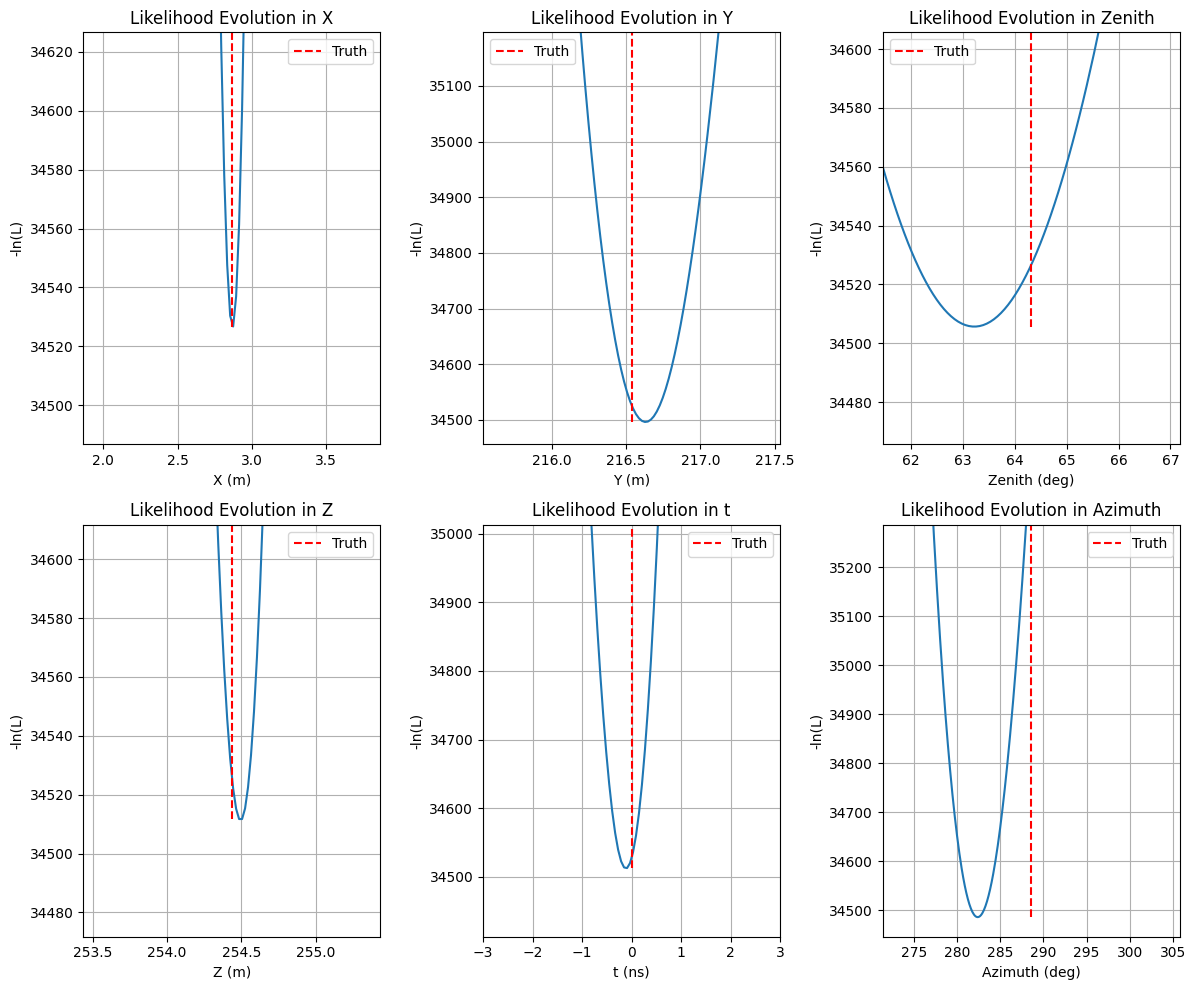

In [21]:
likelihood_graphs(np.array([2.86453,216.537,254.435, 5.03732, 1.12255, 0]), likelihood_data, 'file_1_likelihood_evo_3d')


In [22]:
def minimizer(guess, event, function=Likelihood_3d):
    # Guess should be xyzt
    minimized = optimize.minimize(function, 
                                  x0=guess,
                                  args=(event),  
                                  method='Nelder-Mead', 
                                  tol=1e-3)
    return minimized

In [23]:
space_angle_ary = np.array([])
energy_ary = np.array([])
for i in range(501):
    if i < 10:
        runnumber = '00' + str(i)
    elif i < 100:
        runnumber = '0' + str(i)
    else:
        runnumber = str(i)
    if os.path.isfile(f'/mnt/scratch/dillonb5/resolutions3/resolution_{runnumber}.npy'):
        #print(runnumber)
        ary = np.load(f'/mnt/scratch/dillonb5/resolutions3/resolution_{runnumber}.npy')
    
        if ary.shape == (0,):
            continue
       

        # zenith_ary = np.concatenate((zenith_ary, ary[:,0]))
        # azimuth_ary = np.concatenate((azimuth_ary, ary[:,1]))
        space_angle_ary = np.concatenate((space_angle_ary, ary[:,0]))
        energy_ary = np.concatenate((energy_ary, ary[:,1]))


In [24]:
len(space_angle_ary)

19487

In [25]:
space_angle_ary = space_angle_ary*360/(2*np.pi)

In [26]:
space_angle_ary

array([42.2152582 ,  7.74530918, 42.55117317, ..., 42.16388222,
        3.57254891,  8.89357075])

In [27]:
count=0
for val in space_angle_ary:
    if not np.isnan(val):
        count+=1
print(count)

19487


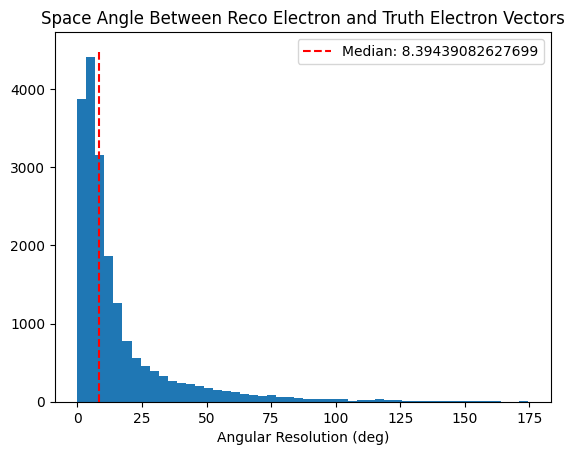

In [28]:
plt.hist(space_angle_ary, 50)
plt.vlines(np.median(space_angle_ary), 0, 4500, colors='red', ls='--', label=f'Median: {np.median(space_angle_ary)}')
plt.title('Space Angle Between Reco Electron and Truth Electron Vectors')
plt.xlabel('Angular Resolution (deg)')
plt.legend()
plt.savefig(
    '/mnt/home/dillonb5/cascades/plots/angular_res_v1.png'
)

In [29]:
hist, edges = np.histogram(energy_ary, bins=np.logspace(2, 6, 17))
print(hist)
print(edges)

[6184 4169 2886 1800 1280  882  639  461  339  223  164  144   95  107
   74   40]
[1.00000000e+02 1.77827941e+02 3.16227766e+02 5.62341325e+02
 1.00000000e+03 1.77827941e+03 3.16227766e+03 5.62341325e+03
 1.00000000e+04 1.77827941e+04 3.16227766e+04 5.62341325e+04
 1.00000000e+05 1.77827941e+05 3.16227766e+05 5.62341325e+05
 1.00000000e+06]


In [30]:
def truncate(f, n):
        '''Truncates/pads a float f to n decimal places without rounding'''
        s = '{}'.format(f)
        if 'e' in s or 'E' in s:
                return '{0:.{1}f}'.format(f, n)
        i, p, d = s.partition('.')
        return '.'.join([i, (d+'0'*n)[:n]])

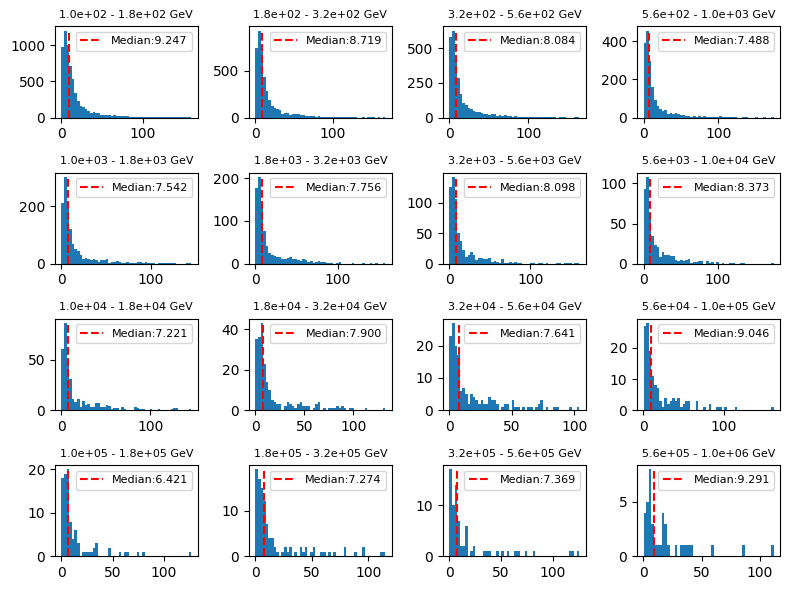

In [31]:
fig, axs = plt.subplots(4,4, figsize = (8,6))
ct = 0
for i in range(len(axs)):
    for j in range(len(axs[i])):
        bin_mask = (energy_ary >= edges[ct]) & (energy_ary < edges[ct + 1])
        bin_res = space_angle_ary[bin_mask]
        counts, _ = np.histogram(bin_res, bins=50)
        axs[i,j].hist(bin_res, bins=50)
        axs[i,j].set_title(f'{edges[ct]:.1e} - {edges[ct+1]:.1e} GeV', fontsize=8)
        axs[i,j].vlines(np.median(bin_res), 0, max(counts), colors='red', ls='--', label=f'Median:{truncate(np.median(bin_res),3)}')
        #axs[i,j].set_xlabel('Angular Resolution (deg)', fontsize=8)
        axs[i,j].legend(fontsize=8)
        
        ct += 1

fig.tight_layout()
plt.savefig('/mnt/home/dillonb5/cascades/plots/angular_res_energy_binned.png')



In [38]:
splinefit_3d.extents

((2.0920000317428116, 279.13374889976023),
 (0.0, 3.141592653589793),
 (-30.726762008826114, 1627.6756954685331))

In [42]:
def cdf(coords, Event):
    t = np.linspace(splinefit_3d.extents[2][0], splinefit_3d.extents[2][1], 2500)
    pvalues = []
    for event in Event:
        dr = displacement_magnitude(coords[0:3], np.array(event[0:3]))
        diff = coords[0:3] - np.array(event[0:3])

        Ex = np.sin(coords[4])*np.cos(coords[3])
        Ey = np.sin(coords[4])*np.sin(coords[3])
        Ez = np.cos(coords[4])


        # Calculate angle between electron travel vector and displacement vector
        Eangle = np.array([Ex, Ey, Ez])
        Ephi = np.arccos(np.dot(diff, Eangle) / dr)
        
        
        #dt = abs(coords[3] - event[3]) - (1.34*dr/c * 1e9)
        pdf = evalPdf(splinefit_3d, dr, Ephi, t)
        cdf = np.sum(pdf[np.searchsorted(t, event[-1]):])/np.sum(pdf)
        pvalues.append(cdf)

    plt.hist(pvalues, bins=np.linspace(min(pvalues),max(pvalues),50))
    plt.xlabel('CDF Value')
    plt.ylabel('Hits')
    plt.title('3D CDF Distribution')

In [33]:
len(EventData5)

53819

In [34]:
print(frame18['I3MCTree'][1])


[ I3Particle MajorID : 15941211553967342775
             MinorID : 614
              Zenith : 1.12255
             Azimuth : 5.03732
                   X : 2.86453
                   Y : 216.537
                   Z : 254.435
                Time : 0
              Energy : 1847.28
               Speed : 0.299792
              Length : nan
                Type : EMinus
        PDG encoding : 11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]


In [35]:
print(frame27['I3MCTree'][1])
print(frame27['I3MCTree'][1].pos)

[ I3Particle MajorID : 15941211553967342775
             MinorID : 956
              Zenith : 2.22391
             Azimuth : 0.938481
                   X : 632.878
                   Y : -456.534
                   Z : -261.346
                Time : 0
              Energy : 11831.7
               Speed : 0.299792
              Length : nan
                Type : EMinus
        PDG encoding : 11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]
I3Position(632.878,-456.534,-261.346)


In [36]:
def cdf_color_plt(coords, Event):
    pvalues = []
    for event in Event:
        dr = displacement_magnitude(coords[0:3], np.array(event[0:3]))
        diff = coords[0:3] - np.array(event[0:3])

        Ex = np.sin(coords[4])*np.cos(coords[3])
        Ey = np.sin(coords[4])*np.sin(coords[3])
        Ez = np.cos(coords[4])


        # Calculate angle between electron travel vector and displacement vector
        Eangle = np.array([Ex, Ey, Ez])
        Ephi = np.arccos(np.dot(diff, Eangle) / dr)
        
        
        #dt = abs(coords[3] - event[3]) - (1.34*dr/c * 1e9)
        pdf = np.exp(splinefit_3d.evaluate_simple([dr,Ephi, t]))
        cdf = np.sum(pdf[np.searchsorted(t, event[-1]):])/np.sum(pdf)
        pvalues.append((cdf, Ephi))
    twoDary = np.array(pvalues)
    #print(twoDary)
    hist, edges = np.histogramdd(twoDary, bins=20)
    print(twoDary)
    
    fig, ax = plt.subplots()
    plot = ax.imshow(
        hist.T,                    # Transpose so axis 0 = x, axis 1 = y
        origin='lower',            # Put (0,0) at bottom-left, not top-left
        aspect='auto',
        norm=LogNorm(vmin=1, vmax=hist.max()),             # Don't force square pixels
        extent=[                   # Map pixel coords to data coords
            edges[0][0], edges[0][-1],   # x: cdf axis range
            edges[1][0], edges[1][-1]    # y: dr axis range
        ]
    )
    cbar = ax.figure.colorbar(plot, ax=ax, )
    cbar.ax.set_ylabel('Bin counts', rotation=-90, va="bottom")
    ax.set_xlabel('CDF')
    ax.set_ylabel('Emission Angle')
    plt.tight_layout()
    plt.show()

In [37]:
cdf_color_plt(np.array([632.878,-456.534,-261.346, 0.938481, 2.22391,0]), EventData2)

NameError: name 't' is not defined

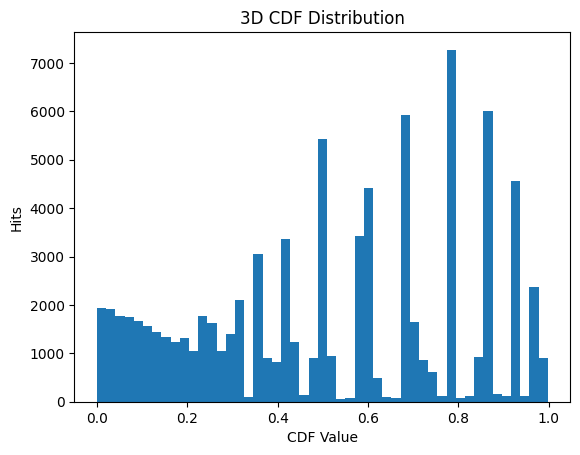

In [43]:
cdf(np.array([632.878,-456.534,-261.346, 0.938481, 2.22391,0]), EventData2)

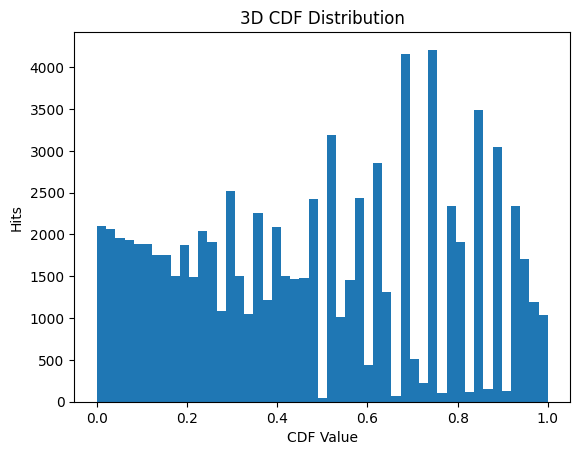

In [ ]:
best_fit = minimizer(np.array([632.878,-456.534,-261.346, 0.938481, 2.22391,0]), EventData2)
cdf(best_fit['x'], EventData2)

In [48]:
def sample_dt(dr, dphi):
    pvalues = []
    spline=splinefit_3d 
    t = np.linspace(spline.extents[-1][0], spline.extents[-1][1], 2000)
    pdf = evalPdf(spline, dr, dphi, t)
    for dt in t:
        cdf = np.sum(pdf[:np.searchsorted(t, dt)])/np.sum(pdf)
        pvalues.append(cdf)
    return t, pvalues

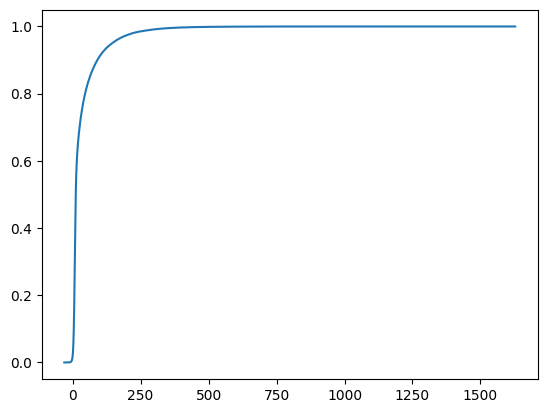

In [56]:
t, p = sample_dt(100, 0)
plt.plot(t, p)